# Homework 2 — Convolutional Neural Networks (SOLVED)

This notebook mirrors the four sections of the PDF:

1. **Convolution Fundamentals** — parameter counting, manual 2D convolution, output-size formula, edge detectors, padding, receptive field.
2. **Pooling** — max vs average pooling, effect on receptive field.
3. **Architecture Analysis** — LeNet-5 parameter accounting, why 3×3 filters dominate.
4. **Backpropagation Through Conv Layers** — gradients with respect to kernel and input, max- and avg-pool gradients (sparse vs dense).

A final **Bonus** section trains a small CNN on MNIST end-to-end.

All numerical answers match the PDF exactly. Run the notebook top-to-bottom; outputs are reproducible thanks to fixed random seeds.

In [1]:
# ============================================================================
# Imports and reproducibility
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

np.set_printoptions(precision=3, suppress=True)
torch.set_printoptions(precision=3)

print(f"PyTorch: {torch.__version__}, NumPy: {np.__version__}")

PyTorch: 2.10.0+cpu, NumPy: 2.0.2


---
## Section 1 — Convolution Fundamentals

### Problem 1 — FC vs Conv parameter counting [5 pts]

Compare a fully-connected layer mapping a flattened $32 \times 32 \times 3$ image to 128 hidden units versus a Conv2d layer with 16 filters of size $5 \times 5$.

**Expected answers** (from the PDF):
- FC: $128 \cdot 3072 + 128 = 393{,}344$
- Conv: $16 \cdot (5 \cdot 5 \cdot 3 + 1) = 1{,}216$
- Ratio: $\approx 323\times$

In [2]:
# (a) Count learnable parameters in any nn.Module
def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

# (b) Fully-connected: 32*32*3 = 3072 inputs -> 128 outputs
fc_layer = nn.Linear(32 * 32 * 3, 128)   # weight: 128x3072, bias: 128

# (c) Conv2d: 16 filters, 5x5, 3 input channels
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5)

# (d) Print counts and ratio
fc_n   = count_params(fc_layer)    # expected: 393,344
conv_n = count_params(conv_layer)  # expected: 1,216

print(f"FC parameters  : {fc_n:>10,}   (128*3072 + 128 = {128*3072+128:,})")
print(f"Conv parameters: {conv_n:>10,}   (16*(5*5*3 + 1) = {16*(5*5*3+1):,})")
print(f"Ratio          : {fc_n / conv_n:.1f}x more parameters in the FC layer")

FC parameters  :    393,344   (128*3072 + 128 = 393,344)
Conv parameters:      1,216   (16*(5*5*3 + 1) = 1,216)
Ratio          : 323.5x more parameters in the FC layer


**Why this works:** Locality + weight sharing. The FC layer connects every output to every input pixel; the Conv layer reuses the same $5 \times 5$ filter at every spatial position. Parameter count for Conv depends only on filter size and channel counts — *not* on the image's spatial dimensions.

### Problem 2 — 2D convolution by hand [8 pts]

Implement 2D cross-correlation from scratch with nested loops, then verify against `torch.nn.functional.conv2d`.

**Setup** (matches the PDF's example):
$$
\mathbf{X} = \begin{pmatrix} 1 & 2 & 3 & 0 & 1 \\ 0 & 1 & 2 & 3 & 1 \\ 2 & 1 & 0 & 1 & 2 \\ 1 & 0 & 2 & 3 & 0 \\ 0 & 1 & 1 & 2 & 1 \end{pmatrix}, \quad
\mathbf{K} = \begin{pmatrix} 1 & 0 & -1 \\ 1 & 0 & -1 \\ 1 & 0 & -1 \end{pmatrix}
$$

In [3]:
# (a) 2D cross-correlation from scratch
def conv2d_naive(X, K, stride=1, padding=0):
    """2D cross-correlation (what PyTorch calls conv2d)."""
    if padding > 0:
        X = np.pad(X, pad_width=padding, mode='constant', constant_values=0)
    H, W   = X.shape
    F, _   = K.shape
    H_out  = (H - F) // stride + 1
    W_out  = (W - F) // stride + 1
    Y = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = X[i*stride : i*stride + F,
                      j*stride : j*stride + F]
            Y[i, j] = np.sum(patch * K)
    return Y


# Test inputs (DO NOT MODIFY)
X = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [2, 1, 0, 1, 2],
    [1, 0, 2, 3, 0],
    [0, 1, 1, 2, 1],
], dtype=float)

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)

# (b) stride=1, padding=0
Y = conv2d_naive(X, K, stride=1, padding=0)
print("Manual output (stride=1, padding=0):")
print(Y)
print(f"Shape: {Y.shape}   # expected (3, 3)")

Manual output (stride=1, padding=0):
[[-2.  0.  1.]
 [-1. -5.  1.]
 [ 0. -4.  0.]]
Shape: (3, 3)   # expected (3, 3)


In [4]:
# Verify against PyTorch
X_t = torch.from_numpy(X).float().reshape(1, 1, 5, 5)
K_t = torch.from_numpy(K).float().reshape(1, 1, 3, 3)
Y_torch = F.conv2d(X_t, K_t, stride=1, padding=0).squeeze().numpy()

print("PyTorch output:")
print(Y_torch)
print(f"\nManual matches PyTorch: {np.allclose(Y, Y_torch)}")

PyTorch output:
[[-2.  0.  1.]
 [-1. -5.  1.]
 [ 0. -4.  0.]]

Manual matches PyTorch: True


In [5]:
# (c) stride=2, padding=1
Y_s2_p1 = conv2d_naive(X, K, stride=2, padding=1)
print("Manual output (stride=2, padding=1):")
print(Y_s2_p1)
print(f"Shape: {Y_s2_p1.shape}")
# Formula: floor((5 + 2*1 - 3)/2) + 1 = floor(4/2) + 1 = 3
print("Expected shape: (3, 3)  [floor((5+2-3)/2)+1 = 3]")

# Verify
Y_torch_s2 = F.conv2d(X_t, K_t, stride=2, padding=1).squeeze().numpy()
print(f"Matches PyTorch: {np.allclose(Y_s2_p1, Y_torch_s2)}")

Manual output (stride=2, padding=1):
[[-3.  0.  3.]
 [-2. -5.  7.]
 [-1. -4.  5.]]
Shape: (3, 3)
Expected shape: (3, 3)  [floor((5+2-3)/2)+1 = 3]
Matches PyTorch: True


### Problem 3 — Output size formula [4 pts]

Verify the formula
$$ W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} + 2P - F}{S} \right\rfloor + 1 $$
on several test cases, then compute the parameter count for a multi-channel layer.

In [6]:
def output_size(W, F, P, S):
    return (W + 2 * P - F) // S + 1


test_cases = [
    (28,   3, 0, 1, 26),
    (28,   3, 1, 1, 28),
    (28,   5, 2, 1, 28),
    (224,  3, 1, 2, 112),
    (224,  7, 3, 2, 112),
]
print(f"{'W':>4} {'F':>3} {'P':>3} {'S':>3}   {'computed':>9} {'expected':>9}  match")
print("-" * 50)
for W, F_, P, S, expected in test_cases:
    out = output_size(W, F_, P, S)
    print(f"{W:>4} {F_:>3} {P:>3} {S:>3}   {out:>9} {expected:>9}  {out == expected}")

   W   F   P   S    computed  expected  match
--------------------------------------------------
  28   3   0   1          26        26  True
  28   3   1   1          28        28  True
  28   5   2   1          28        28  True
 224   3   1   2         112       112  True
 224   7   3   2         112       112  True


In [7]:
def conv_params(F, C_in, C_out):
    """Parameter count for Conv2d(C_in, C_out, F) including biases."""
    return C_out * (F * F * C_in + 1)


# ResNet first conv: 7x7, 3 -> 64
p = conv_params(7, 3, 64)
print(f"ResNet Conv1 (7x7, 3->64): {p:,} parameters")
print(f"  = 64 * (7*7*3 + 1) = 64 * 148 = {64*148:,}  ✓")
print(f"Output shape: {output_size(224, 7, 3, 2)} x {output_size(224, 7, 3, 2)} x 64")

ResNet Conv1 (7x7, 3->64): 9,472 parameters
  = 64 * (7*7*3 + 1) = 64 * 148 = 9,472  ✓
Output shape: 112 x 112 x 64


### Problem 4 — Edge detector demo [4 pts]

Vertical edge kernel (K_v):
[[ 1.  0. -1.]
 [ 2.  0. -2.]
 [ 1.  0. -1.]]

Horizontal edge kernel (K_h = K_v.T):
[[ 1.  2.  1.]
 [ 0.  0.  0.]
 [-1. -2. -1.]]


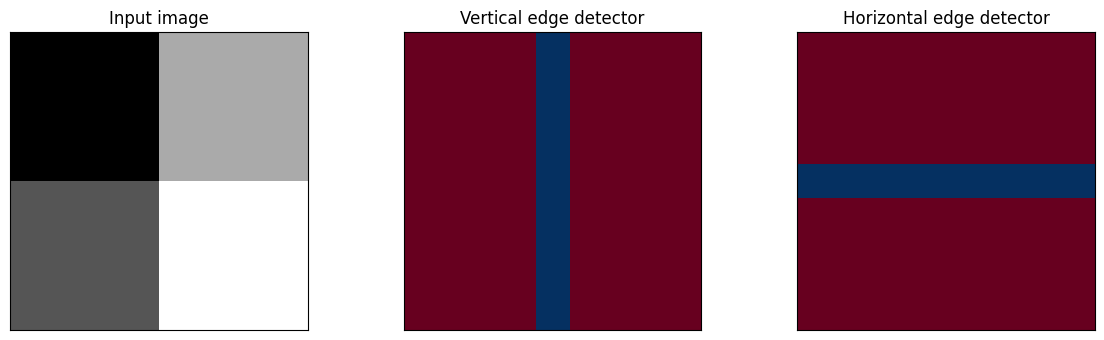


Vertical edge: strong response at column 9 (vertical boundary left-to-right).
Horizontal edge: strong response at row 9 (horizontal boundary top-to-bottom).


In [8]:
# Synthetic image (DO NOT MODIFY)
img = np.zeros((20, 20))
img[:, 10:] = 1.0
img[10:, :] = img[10:, :] + 0.5

# Sobel-style vertical edge detector: detects left-to-right intensity changes
# Strong positive response at vertical edges (intensity rises left to right)
K_v = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1],
], dtype=float)

# Horizontal edge detector = transpose of vertical (detects top-to-bottom changes)
K_h = K_v.T

print("Vertical edge kernel (K_v):")
print(K_v)
print("\nHorizontal edge kernel (K_h = K_v.T):")
print(K_h)

out_v = conv2d_naive(img, K_v)
out_h = conv2d_naive(img, K_h)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=1.5); axes[0].set_title("Input image")
axes[1].imshow(out_v, cmap="RdBu_r");               axes[1].set_title("Vertical edge detector")
axes[2].imshow(out_h, cmap="RdBu_r");               axes[2].set_title("Horizontal edge detector")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("\nVertical edge: strong response at column 9 (vertical boundary left-to-right).")
print("Horizontal edge: strong response at row 9 (horizontal boundary top-to-bottom).")

### Problem 5 — Padding modes [4 pts]

In [9]:
np.random.seed(0)
X_pad = np.random.rand(8, 8)
F_size = 3
K_uniform = np.ones((F_size, F_size)) / F_size**2  # box blur

# Valid: P=0 → output shrinks by F-1 = 2 pixels per side
Y_valid = conv2d_naive(X_pad, K_uniform, stride=1, padding=0)

# Same: P=(F-1)/2 = 1 → output preserves spatial size
Y_same  = conv2d_naive(X_pad, K_uniform, stride=1, padding=(F_size - 1) // 2)

# Full: P=F-1=2 → output grows by F-1 = 2 pixels per side
Y_full  = conv2d_naive(X_pad, K_uniform, stride=1, padding=F_size - 1)

print(f"Input shape : {X_pad.shape}")
print(f"Valid (P=0) : {Y_valid.shape}   expected ({8-F_size+1}, {8-F_size+1})")
print(f"Same  (P=1) : {Y_same.shape}   expected (8, 8)")
print(f"Full  (P=2) : {Y_full.shape}   expected ({8+F_size-1}, {8+F_size-1})")

print("\nFormula verification (stride=1):")
for mode, P, Y_out in [("valid", 0, Y_valid), ("same", 1, Y_same), ("full", 2, Y_full)]:
    computed = output_size(8, F_size, P, 1)
    print(f"  {mode:5s}  P={P}  formula={computed}  actual={Y_out.shape[0]}  ✓={computed==Y_out.shape[0]}")

Input shape : (8, 8)
Valid (P=0) : (6, 6)   expected (6, 6)
Same  (P=1) : (8, 8)   expected (8, 8)
Full  (P=2) : (10, 10)   expected (10, 10)

Formula verification (stride=1):
  valid  P=0  formula=6  actual=6  ✓=True
  same   P=1  formula=8  actual=8  ✓=True
  full   P=2  formula=10  actual=10  ✓=True


### Problem 6 — Receptive field walkthrough [4 pts]

In [10]:
def compute_rf(layers):
    """
    Compute receptive field at each layer.
    layers: list of (F, S) tuples.
    Returns list of dicts with keys: layer, op, j, RF.
    """
    j, RF = 1, 1
    history = [{"layer": 0, "op": "Input", "j": j, "RF": RF}]
    for idx, (F, S) in enumerate(layers, start=1):
        op = f"Conv {F}x{F}" if S == 1 else f"Pool {F}x{F} s={S}"
        RF = RF + (F - 1) * j
        j  = j * S
        history.append({"layer": idx, "op": op, "j": j, "RF": RF})
    return history


# Network from Problem 6: Conv5 -> Pool2 -> Conv5 -> Pool2 -> Conv3
network = [(5, 1), (2, 2), (5, 1), (2, 2), (3, 1)]
history = compute_rf(network)

print(f"{'Layer':>5}  {'Operation':<16}  {'j':>3}  {'RF':>3}")
print("-" * 38)
for h in history:
    print(f"{h['layer']:>5}  {h['op']:<16}  {h['j']:>3}  {h['RF']:>3}")
print(f"\nFinal receptive field: {history[-1]['RF']} x {history[-1]['RF']} pixels")
print(f"Expected: 24 x 24  ✓={history[-1]['RF'] == 24}")

Layer  Operation           j   RF
--------------------------------------
    0  Input               1    1
    1  Conv 5x5            1    5
    2  Pool 2x2 s=2        2    6
    3  Conv 5x5            2   14
    4  Pool 2x2 s=2        4   16
    5  Conv 3x3            4   24

Final receptive field: 24 x 24 pixels
Expected: 24 x 24  ✓=True


---
## Section 2 — Pooling

### Problem 7 — Max vs average pooling [4 pts]

In [11]:
X_pool = np.array([
    [2, 5, 1, 3],
    [4, 1, 8, 0],
    [7, 2, 1, 4],
    [3, 0, 6, 9],
], dtype=float)

def maxpool2x2(X):
    H, W = X.shape
    out = np.zeros((H // 2, W // 2))
    for i in range(H // 2):
        for j in range(W // 2):
            out[i, j] = X[2*i:2*i+2, 2*j:2*j+2].max()
    return out

def avgpool2x2(X):
    H, W = X.shape
    out = np.zeros((H // 2, W // 2))
    for i in range(H // 2):
        for j in range(W // 2):
            out[i, j] = X[2*i:2*i+2, 2*j:2*j+2].mean()
    return out

print("Max pool (manual):")
print(maxpool2x2(X_pool))
print("\nAvg pool (manual):")
print(avgpool2x2(X_pool))

# Verify with PyTorch
X_t_pool = torch.from_numpy(X_pool).float().reshape(1, 1, 4, 4)
print("\nMax pool (PyTorch):")
print(F.max_pool2d(X_t_pool, 2).squeeze().numpy())
print("\nAvg pool (PyTorch):")
print(F.avg_pool2d(X_t_pool, 2).squeeze().numpy())

print(f"\nMax matches PyTorch: {np.allclose(maxpool2x2(X_pool), F.max_pool2d(X_t_pool, 2).squeeze().numpy())}")
print(f"Avg matches PyTorch: {np.allclose(avgpool2x2(X_pool), F.avg_pool2d(X_t_pool, 2).squeeze().numpy())}")

Max pool (manual):
[[5. 8.]
 [7. 9.]]

Avg pool (manual):
[[3. 3.]
 [3. 5.]]

Max pool (PyTorch):
[[5. 8.]
 [7. 9.]]

Avg pool (PyTorch):
[[3. 3.]
 [3. 5.]]

Max matches PyTorch: True
Avg matches PyTorch: True


**When to use which.** Max pool is the standard choice for detection-like tasks (it preserves the strongest local activation). Average pool is preferred for the *final* aggregation in modern architectures (e.g., global average pooling in ResNet) because it retains more information.

### Problem 8 — Pooling effect on receptive field [4 pts]

In [12]:
# Conv 3x3 -> Conv 3x3 -> MaxPool 2x2 (s=2) -> Conv 3x3 -> Conv 3x3
network8 = [(3, 1), (3, 1), (2, 2), (3, 1), (3, 1)]
history8 = compute_rf(network8)

print(f"{'Layer':>5}  {'Operation':<16}  {'j':>3}  {'RF':>3}")
print("-" * 38)
for h in history8:
    print(f"{h['layer']:>5}  {h['op']:<16}  {h['j']:>3}  {h['RF']:>3}")
print(f"\nFinal receptive field: {history8[-1]['RF']} x {history8[-1]['RF']}")
print("\nKey observation: MaxPool added only 1 to RF directly but DOUBLED j.")
print("Each subsequent Conv3 gains 2*j=4 pixels of RF (instead of 2 without the pool).")
print("The pool's real power is the jump multiplier, not its own RF contribution.")

Layer  Operation           j   RF
--------------------------------------
    0  Input               1    1
    1  Conv 3x3            1    3
    2  Conv 3x3            1    5
    3  Pool 2x2 s=2        2    6
    4  Conv 3x3            2   10
    5  Conv 3x3            2   14

Final receptive field: 14 x 14

Key observation: MaxPool added only 1 to RF directly but DOUBLED j.
Each subsequent Conv3 gains 2*j=4 pixels of RF (instead of 2 without the pool).
The pool's real power is the jump multiplier, not its own RF contribution.


---
## Section 3 — Architecture Analysis

### Problem 9 — LeNet-5 parameter count [7 pts]

Expected breakdown:
- Conv $5\times5$, 1→6:  $5\cdot5\cdot1\cdot6 + 6 = 156$
- Conv $5\times5$, 6→16: $5\cdot5\cdot6\cdot16 + 16 = 2{,}416$
- FC $400\to120$: $48{,}120$
- FC $120\to84$:  $10{,}164$
- FC $84\to10$:    $850$

Total: **61,706**.

In [13]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)    # 32->28, 156 params
        self.pool1 = nn.AvgPool2d(2, stride=2)          # 28->14, 0 params
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)   # 14->10, 2416 params
        self.pool2 = nn.AvgPool2d(2, stride=2)          # 10->5,  0 params
        self.fc1   = nn.Linear(16 * 5 * 5, 120)         # 48120 params
        self.fc2   = nn.Linear(120, 84)                  # 10164 params
        self.fc3   = nn.Linear(84, 10)                   # 850 params

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = x.flatten(start_dim=1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


lenet = LeNet5()

print("LeNet-5 parameter breakdown:")
print("-" * 50)
total = 0
for name, layer in lenet.named_children():
    n = count_params(layer)
    print(f"  {name:>6}: {n:>10,} parameters")
    total += n
print("-" * 50)
print(f"  {'TOTAL':>6}: {total:>10,} parameters")
print(f"\nMatches PDF expected value (61,706): {total == 61706}")

# Sanity check: forward pass
dummy = torch.zeros(1, 1, 32, 32)
out = lenet(dummy)
print(f"Forward pass output shape: {out.shape}  (expected (1, 10))")

LeNet-5 parameter breakdown:
--------------------------------------------------
   conv1:        156 parameters
   pool1:          0 parameters
   conv2:      2,416 parameters
   pool2:          0 parameters
     fc1:     48,120 parameters
     fc2:     10,164 parameters
     fc3:        850 parameters
--------------------------------------------------
   TOTAL:     61,706 parameters

Matches PDF expected value (61,706): True
Forward pass output shape: torch.Size([1, 10])  (expected (1, 10))


In [14]:
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32, 300), nn.Tanh(),
    nn.Linear(300, 300),     nn.Tanh(),
    nn.Linear(300, 10),
)
mlp_params = count_params(mlp)
print(f"Equivalent MLP (32*32 -> 300 -> 300 -> 10): {mlp_params:,} parameters")
print(f"MLP / LeNet-5 ratio: {mlp_params / total:.2f}x more parameters in the MLP")

Equivalent MLP (32*32 -> 300 -> 300 -> 10): 400,810 parameters
MLP / LeNet-5 ratio: 6.50x more parameters in the MLP


### Problem 10 — Why $3 \times 3$ filters dominate [7 pts]

In [15]:
C = 64  # channels in and out

# Architecture A: single 5x5 conv, C -> C, padding=2 ("same")
arch_a = nn.Conv2d(C, C, kernel_size=5, padding=2)

# Architecture B: two stacked 3x3 convs with a ReLU between, each C -> C, padding=1
arch_b = nn.Sequential(
    nn.Conv2d(C, C, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(C, C, kernel_size=3, padding=1),
)

a_params = count_params(arch_a)
b_params = count_params(arch_b)

print(f"Architecture A (one 5x5):      {a_params:>10,} parameters   RF=5   1 ReLU")
print(f"Architecture B (two 3x3):      {b_params:>10,} parameters   RF=5   2 ReLUs")
print(f"Params ratio B/A:              {b_params / a_params:.3f}x  (B uses {100*(1-b_params/a_params):.0f}% fewer parameters)")
print("\nVerify RF: two 3x3 convs → RF = 3 + (3-1)*1 = 5. Same as one 5x5. ✓")

Architecture A (one 5x5):         102,464 parameters   RF=5   1 ReLU
Architecture B (two 3x3):          73,856 parameters   RF=5   2 ReLUs
Params ratio B/A:              0.721x  (B uses 28% fewer parameters)

Verify RF: two 3x3 convs → RF = 3 + (3-1)*1 = 5. Same as one 5x5. ✓


In [16]:
# Generalize: n stacked 3x3 convs vs one (2n+1)x(2n+1) conv
print(f"{'n':>2}  {'RF':>3}  {'stacked 3x3 params':>22}  {'single conv params':>22}  {'savings':>10}")
print("-" * 68)
for n in [1, 2, 3, 4, 5]:
    rf = 2 * n + 1
    p_stacked = n * (3 * 3 * C * C)      # biases ignored
    p_single  = rf * rf * C * C
    savings = 100 * (1 - p_stacked / p_single)
    print(f"{n:>2}  {rf:>3}  {p_stacked:>22,}  {p_single:>22,}  {savings:>9.0f}%")

 n   RF      stacked 3x3 params      single conv params     savings
--------------------------------------------------------------------
 1    3                  36,864                  36,864          0%
 2    5                  73,728                 102,400         28%
 3    7                 110,592                 200,704         45%
 4    9                 147,456                 331,776         56%
 5   11                 184,320                 495,616         63%


---
## Section 4 — Backpropagation Through Conv Layers

### Problem 11 — Gradient with respect to the kernel [10 pts]

For 1D convolution $y_i = \sum_u x_{i+u} K_u$:
$$\frac{\partial \mathcal{L}}{\partial K_u} = \sum_i \delta_i \, x_{i+u}$$
This is a cross-correlation of $\mathbf{x}$ with $\boldsymbol{\delta}$ — the kernel gradient is itself a convolution.

In [17]:
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
K_1d = np.array([0.5, -0.5, 1.0])
n, k = len(x), len(K_1d)

# (a) Forward pass
y = np.zeros(n - k + 1)
for i in range(n - k + 1):
    y[i] = np.dot(x[i : i + k], K_1d)

print(f"y = {y}")
# expected: y[0] = 1*0.5 + 2*(-0.5) + 3*1.0 = 2.5
#           y[1] = 2*0.5 + 3*(-0.5) + 4*1.0 = 3.5
#           y[2] = 3*0.5 + 4*(-0.5) + 5*1.0 = 4.5

delta = np.ones(n - k + 1)  # upstream gradient (loss = sum(y))

# (b) Manually compute dL/dK
dK_manual = np.zeros(k)
for u in range(k):
    for i in range(n - k + 1):
        dK_manual[u] += delta[i] * x[i + u]

print(f"Manual  dL/dK = {dK_manual}")
# expected: [6, 9, 12]  (sum of x[0:3], x[1:4], x[2:5])

y = [2.5 3.5 4.5]
Manual  dL/dK = [ 6.  9. 12.]


In [18]:
# Verify against PyTorch autograd
x_t = torch.tensor([[[1.0, 2.0, 3.0, 4.0, 5.0]]])             # (1, 1, 5)
K_t = torch.tensor([[[0.5, -0.5, 1.0]]], requires_grad=True)  # (1, 1, 3)

y_t = F.conv1d(x_t, K_t)
loss = y_t.sum()    # upstream gradient = ones
loss.backward()

dK_torch = K_t.grad.squeeze().numpy()
print(f"PyTorch dL/dK = {dK_torch}")
print(f"\nManual matches PyTorch: {np.allclose(dK_manual, dK_torch)}")

PyTorch dL/dK = [ 6.  9. 12.]

Manual matches PyTorch: True


**Why this matters:** The kernel gradient formula $\partial\mathcal{L}/\partial K_u = \sum_i \delta_i x_{i+u}$ is exactly a cross-correlation of $\mathbf{x}$ with $\boldsymbol{\delta}$. This is why `Conv2d.backward()` in PyTorch is implemented as another convolution call — forward and backward have identical mathematical structure, only different operands.

### Problem 12 — Max-pool gradient (sparse) [5 pts]

In [19]:
X12 = torch.tensor([[[[1.0, 3.0, 2.0, 0.0],
                       [5.0, 4.0, 1.0, 6.0],
                       [0.0, 2.0, 7.0, 3.0],
                       [1.0, 1.0, 5.0, 8.0]]]], requires_grad=True)  # leaf (1,1,4,4)

# Apply 2x2 max pooling with stride 2
y12 = F.max_pool2d(X12, 2)
print(f"Max pool output:\n{y12.squeeze().detach().numpy()}")

# Upstream gradient delta shape (1,1,2,2) = [[1,2],[3,4]]
delta12 = torch.tensor([[[[1.0, 2.0], [3.0, 4.0]]]])

# Backpropagate
y12.backward(gradient=delta12)

print(f"\ndL/dX (max pool backward — sparse):")
print(X12.grad.squeeze().numpy())
print("\nExpected: one nonzero per 2x2 window, at the argmax position.")
print("Window (0,0): max=5 at (1,0) → gets delta=1")
print("Window (0,1): max=6 at (1,3) → gets delta=2")
print("Window (1,0): max=2 at (2,1) → gets delta=3")
print("Window (1,1): max=8 at (3,3) → gets delta=4")


Max pool output:
[[5. 6.]
 [2. 8.]]

dL/dX (max pool backward — sparse):
[[0. 0. 0. 0.]
 [1. 0. 0. 2.]
 [0. 3. 0. 0.]
 [0. 0. 0. 4.]]

Expected: one nonzero per 2x2 window, at the argmax position.
Window (0,0): max=5 at (1,0) → gets delta=1
Window (0,1): max=6 at (1,3) → gets delta=2
Window (1,0): max=2 at (2,1) → gets delta=3
Window (1,1): max=8 at (3,3) → gets delta=4


### Problem 13 — Avg-pool gradient (dense) [5 pts]

In [20]:
X13 = torch.tensor([[[[1.0, 3.0, 2.0, 0.0],
                       [5.0, 4.0, 1.0, 6.0],
                       [0.0, 2.0, 7.0, 3.0],
                       [1.0, 1.0, 5.0, 8.0]]]], requires_grad=True)  # leaf (1,1,4,4)

# Apply 2x2 average pooling with stride 2
y13 = F.avg_pool2d(X13, 2)
print(f"Avg pool output:\n{y13.squeeze().detach().numpy()}")

# Same upstream gradient as Problem 12
delta13 = torch.tensor([[[[1.0, 2.0], [3.0, 4.0]]]])

y13.backward(gradient=delta13)

print(f"\ndL/dX (avg pool backward — dense):")
print(X13.grad.squeeze().numpy())
print("\nExpected: every position in each 2x2 window receives delta/4.")
print("Top-left (delta=1):  each position gets 0.25")
print("Top-right (delta=2): each position gets 0.50")
print("Bot-left (delta=3):  each position gets 0.75")
print("Bot-right (delta=4): each position gets 1.00")


Avg pool output:
[[3.25 2.25]
 [1.   5.75]]

dL/dX (avg pool backward — dense):
[[0.25 0.25 0.5  0.5 ]
 [0.25 0.25 0.5  0.5 ]
 [0.75 0.75 1.   1.  ]
 [0.75 0.75 1.   1.  ]]

Expected: every position in each 2x2 window receives delta/4.
Top-left (delta=1):  each position gets 0.25
Top-right (delta=2): each position gets 0.50
Bot-left (delta=3):  each position gets 0.75
Bot-right (delta=4): each position gets 1.00


**Practical consequence.** Max pool can leave 'dead' positions that never receive gradient (never the argmax). Average pool always updates every position, but its gradient signal is diluted by $1/k^2$.

---
## Bonus — End-to-end MNIST CNN

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64,  shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

print(f"Training:  {len(train_ds):>6,} samples")
print(f"Test:      {len(test_ds):>6,} samples")
print(f"One image: {train_ds[0][0].shape}  (channels, height, width)")

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Training:  60,000 samples
Test:      10,000 samples
One image: torch.Size([1, 28, 28])  (channels, height, width)


In [22]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 1x28x28 -> 16x14x14
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        # Block 2: 16x14x14 -> 32x7x7
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        # FC head
        self.fc1   = nn.Linear(32 * 7 * 7, 64)
        self.drop  = nn.Dropout(0.25)
        self.fc2   = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)                   # 28->14
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)                   # 14->7
        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x


cnn = SmallCNN()
print(cnn)
print(f"\nTotal parameters: {count_params(cnn):,}")

SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

Total parameters: 105,962


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn = cnn.to(device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print(f"Training on {device}")
print("-" * 60)
n_epochs = 3
for epoch in range(1, n_epochs + 1):
    cnn.train()
    train_loss = 0.0
    for X_, y_ in train_loader:
        X_, y_ = X_.to(device), y_.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn(X_), y_)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    cnn.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_, y_ in test_loader:
            X_, y_ = X_.to(device), y_.to(device)
            preds = cnn(X_).argmax(dim=1)
            correct += (preds == y_).sum().item()
            total   += y_.size(0)

    print(f"Epoch {epoch}/{n_epochs}: "
          f"train loss {train_loss / len(train_loader):.4f}  "
          f"test accuracy {100 * correct / total:.2f}%")

Training on cpu
------------------------------------------------------------
Epoch 1/3: train loss 0.2045  test accuracy 98.46%
Epoch 2/3: train loss 0.0757  test accuracy 98.78%
Epoch 3/3: train loss 0.0607  test accuracy 98.54%


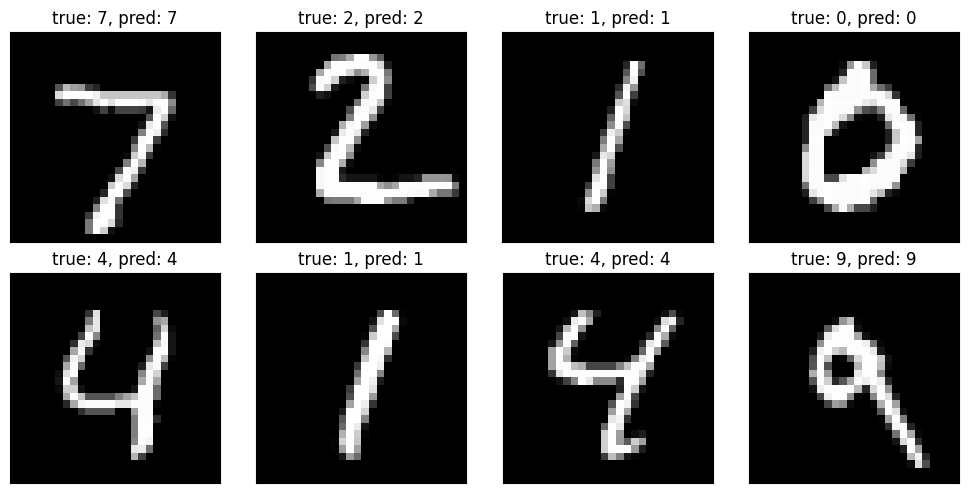

In [24]:
cnn.eval()
X_sample, y_sample = next(iter(test_loader))
X_sample, y_sample = X_sample[:8], y_sample[:8]
with torch.no_grad():
    preds = cnn(X_sample.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_sample[i].squeeze(), cmap="gray")
    correct_pred = preds[i].item() == y_sample[i].item()
    ax.set_title(f"true: {y_sample[i].item()}, pred: {preds[i].item()}",
                 color="black" if correct_pred else "red")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

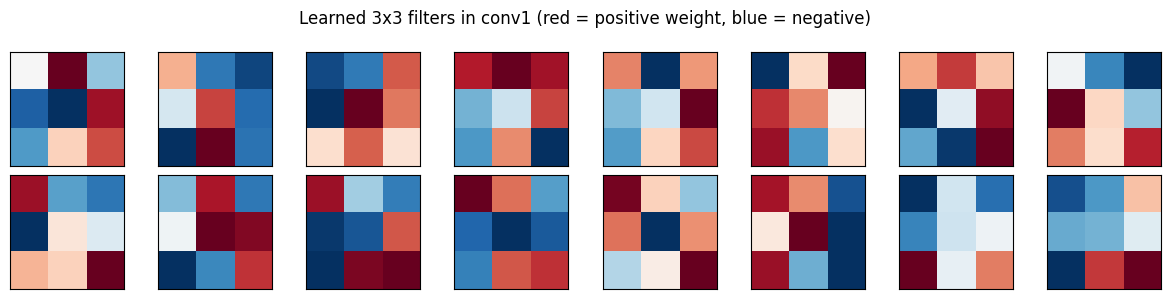

Some filters look like edge detectors — exactly the patterns
hand-designed in Problem 4. The network rediscovered them from data.


In [25]:
filters = cnn.conv1.weight.data.cpu().numpy()  # (16, 1, 3, 3)
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(filters[i, 0], cmap="RdBu_r")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Learned 3x3 filters in conv1 (red = positive weight, blue = negative)")
plt.tight_layout()
plt.show()

print("Some filters look like edge detectors — exactly the patterns")
print("hand-designed in Problem 4. The network rediscovered them from data.")